# Phase 2 — Hypothesis Testing

**Dataset:** Student Performance (UCI) — `student_mat_clean.csv`  
**Mục tiêu:**
- Kiểm định các giả thuyết về yếu tố ảnh học đến G3
- Báo cáo p-value và effect size cho mỗi test
- Export các hình vẽ vào `report/figures/` với prefix `hyp_*`

---
> **Output của notebook này:**  
> `report/figures/hyp_*.png`  
> Bảng summary trong notebook


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings("ignore")

# ── Hằng số dùng chung ──
RANDOM_SEED = 42
ALPHA = 0.05
FIGURES_DIR = "../report/figures"
DATA_IN = "../data/processed/student_mat_clean.csv"

os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight"})

print("Setup hoàn tất.")
print(f"  ALPHA       = {ALPHA}")
print(f"  FIGURES_DIR = {FIGURES_DIR}")
print(f"  DATA_IN     = {DATA_IN}")


Setup hoàn tất.
  ALPHA       = 0.05
  FIGURES_DIR = ../report/figures
  DATA_IN     = ../data/processed/student_mat_clean.csv


## 1. Load dữ liệu

In [2]:
df_clean = pd.read_csv(DATA_IN)
print(f"Shape: {df_clean.shape}")
df_clean.head()


Shape: (357, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Hàm hỗ trợ

In [3]:
def shapiro_by_group(df, group_col, target):
    results = {}
    for group, subset in df.groupby(group_col):
        vals = subset[target].values
        if len(vals) < 3:
            # Shapiro-Wilk test requires at least 3 samples
            results[group] = {"stat": np.nan, "p": 0.0}
        else:
            stat, p = stats.shapiro(vals)
            results[group] = {"stat": stat, "p": p}
    normal = all(v["p"] >= ALPHA for v in results.values())
    return results, normal


def cohen_d(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    n1, n2 = len(x), len(y)
    s1, s2 = np.var(x, ddof=1), np.var(y, ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    if s_pooled == 0:
        return 0.0
    return (np.mean(x) - np.mean(y)) / s_pooled


def mannwhitney_r(x, y):
    u, p = stats.mannwhitneyu(x, y, alternative="two-sided")
    n1, n2 = len(x), len(y)
    mean_u = n1 * n2 / 2
    sd_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    if sd_u == 0:
        z = 0.0
    elif u > mean_u:
        z = (u - mean_u - 0.5) / sd_u
    else:
        z = (u - mean_u + 0.5) / sd_u
    r = z / np.sqrt(n1 + n2)
    return u, p, r


def eta_squared_oneway(groups):
    all_values = np.concatenate(groups)
    grand_mean = np.mean(all_values)
    ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
    ss_total = np.sum((all_values - grand_mean) ** 2)
    if ss_total == 0:
        return 0.0
    return ss_between / ss_total


def epsilon_squared_kruskal(h, k, n):
    if n - k == 0:
        return 0.0
    return (h - k + 1) / (n - k)


summary_rows = []


def add_summary(hypothesis, test_name, stat_name, stat_value, p_value, effect_name, effect_value, note=""):
    summary_rows.append({
        "Hypothesis": hypothesis,
        "Test": test_name,
        "Statistic": stat_name,
        "Stat Value": stat_value,
        "p-value": p_value,
        "Effect Size": effect_name,
        "Effect Value": effect_value,
        "Note": note
    })


## 3. Hypothesis tests

### H1: Giới tính (sex) và G3

Normality Check: {'F': {'stat': 0.9785573239282684, 'p': 0.006042277191270138}, 'M': {'stat': 0.978814163325641, 'p': 0.009934040652457031}}, Normal OK: False


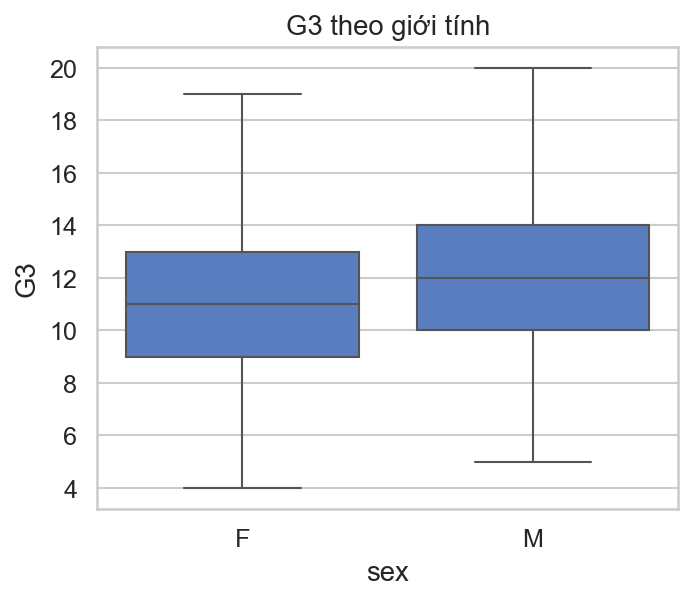

In [4]:
group_col = "sex"
target = "G3"
normality, normal_ok = shapiro_by_group(df_clean, group_col, target)
print(f"Normality Check: {normality}, Normal OK: {normal_ok}")

groups = [g[target].values for _, g in df_clean.groupby(group_col)]
x, y = groups[0], groups[1]

if normal_ok:
    t_stat, p = stats.ttest_ind(x, y, equal_var=False)
    d = cohen_d(x, y)
    add_summary("H1: sex vs G3", "Welch t-test", "t", t_stat, p, "Cohen's d", d)
else:
    u, p, r = mannwhitney_r(x, y)
    add_summary("H1: sex vs G3", "Mann-Whitney U", "U", u, p, "r", r)

plt.figure(figsize=(5, 4))
sns.boxplot(data=df_clean, x=group_col, y=target)
plt.title("G3 theo giới tính")
plt.savefig(f"{FIGURES_DIR}/hyp_h1_sex_g3.png")
plt.show()


### H2: Khu vực (address) và G3

Normality Check: {'R': {'stat': 0.9693760552317306, 'p': 0.05704898250315689}, 'U': {'stat': 0.9806112404604146, 'p': 0.0007682723679142363}}, Normal OK: False


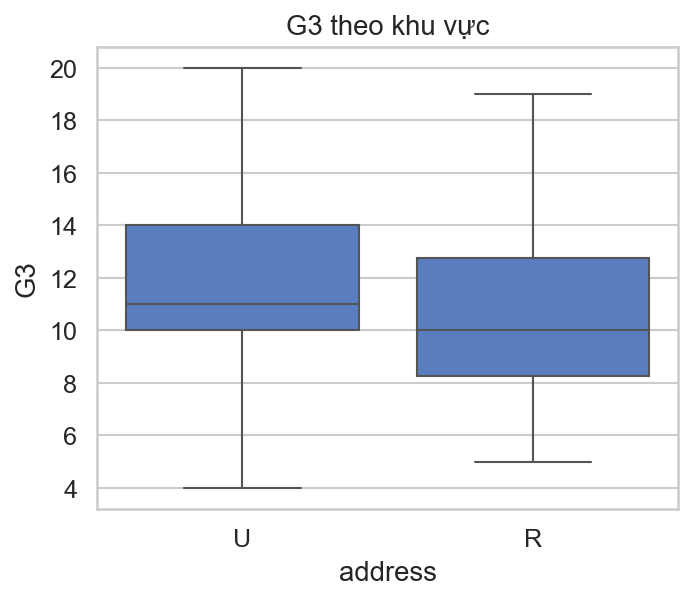

In [5]:
group_col = "address"
target = "G3"
normality, normal_ok = shapiro_by_group(df_clean, group_col, target)
print(f"Normality Check: {normality}, Normal OK: {normal_ok}")

groups = [g[target].values for _, g in df_clean.groupby(group_col)]
x, y = groups[0], groups[1]

if normal_ok:
    t_stat, p = stats.ttest_ind(x, y, equal_var=False)
    d = cohen_d(x, y)
    add_summary("H2: address vs G3", "Welch t-test", "t", t_stat, p, "Cohen's d", d)
else:
    u, p, r = mannwhitney_r(x, y)
    add_summary("H2: address vs G3", "Mann-Whitney U", "U", u, p, "r", r)

plt.figure(figsize=(5, 4))
sns.boxplot(data=df_clean, x=group_col, y=target)
plt.title("G3 theo khu vực")
plt.savefig(f"{FIGURES_DIR}/hyp_h2_address_g3.png")
plt.show()


### H3: Hỗ trợ gia đình (famsup) và G3

Normality Check: {'no': {'stat': 0.9812049026568509, 'p': 0.05421395798342519}, 'yes': {'stat': 0.9761985799429465, 'p': 0.0009292400799305539}}, Normal OK: False


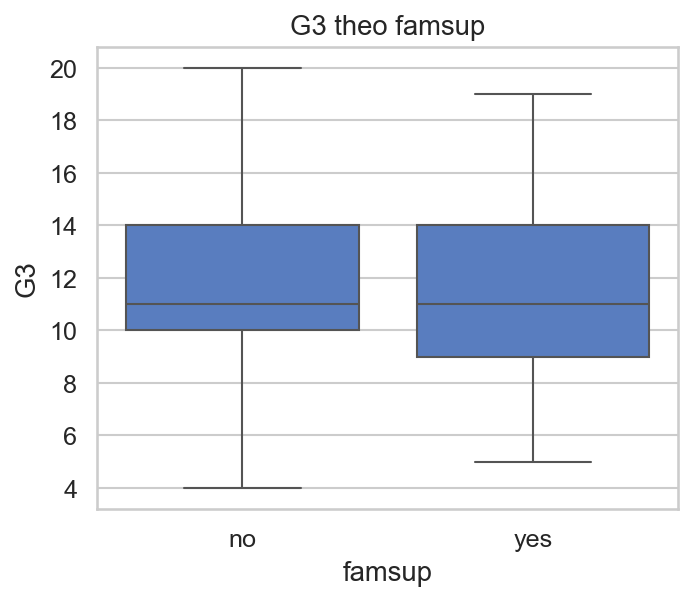

In [6]:
group_col = "famsup"
target = "G3"
normality, normal_ok = shapiro_by_group(df_clean, group_col, target)
print(f"Normality Check: {normality}, Normal OK: {normal_ok}")

groups = [g[target].values for _, g in df_clean.groupby(group_col)]
x, y = groups[0], groups[1]

if normal_ok:
    t_stat, p = stats.ttest_ind(x, y, equal_var=False)
    d = cohen_d(x, y)
    add_summary("H3: famsup vs G3", "Welch t-test", "t", t_stat, p, "Cohen's d", d)
else:
    u, p, r = mannwhitney_r(x, y)
    add_summary("H3: famsup vs G3", "Mann-Whitney U", "U", u, p, "r", r)

plt.figure(figsize=(5, 4))
sns.boxplot(data=df_clean, x=group_col, y=target)
plt.title("G3 theo famsup")
plt.savefig(f"{FIGURES_DIR}/hyp_h3_famsup_g3.png")
plt.show()


### H4: Thời gian học (studytime) và G3

Normality Check: {1: {'stat': 0.9738824957348582, 'p': 0.06133734276802683}, 2: {'stat': 0.9803696688684729, 'p': 0.011515699885995745}, 3: {'stat': 0.960818713805705, 'p': 0.05490672309963608}, 4: {'stat': 0.9798719618709696, 'p': 0.8934938724997304}}, Normal OK: False


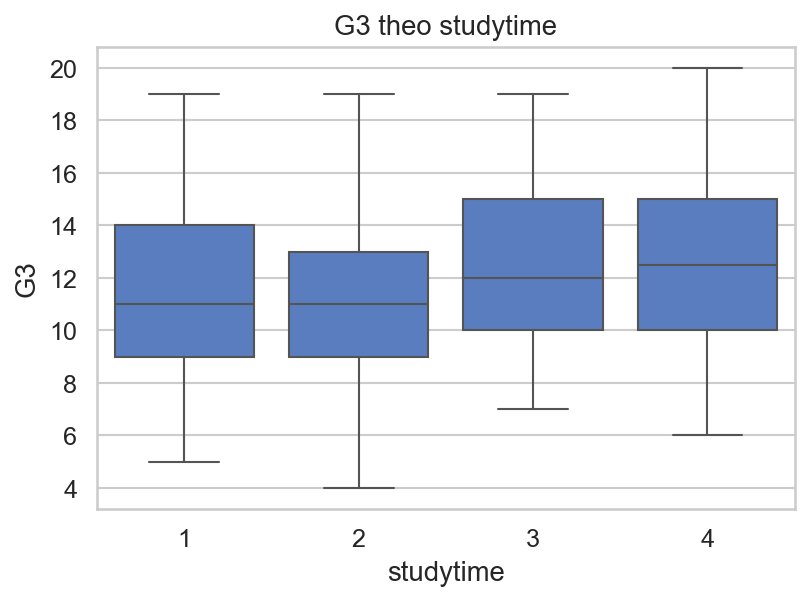

In [7]:
group_col = "studytime"
target = "G3"
normality, normal_ok = shapiro_by_group(df_clean, group_col, target)
print(f"Normality Check: {normality}, Normal OK: {normal_ok}")

groups = [g[target].values for _, g in df_clean.groupby(group_col)]
k = len(groups)
n = sum(len(g) for g in groups)

if normal_ok:
    f_stat, p = stats.f_oneway(*groups)
    eta_sq = eta_squared_oneway(groups)
    add_summary("H4: studytime vs G3", "One-way ANOVA", "F", f_stat, p, "eta^2", eta_sq)
else:
    h_stat, p = stats.kruskal(*groups)
    eps_sq = epsilon_squared_kruskal(h_stat, k, n)
    add_summary("H4: studytime vs G3", "Kruskal-Wallis", "H", h_stat, p, "epsilon^2", eps_sq)

plt.figure(figsize=(6, 4))
sns.boxplot(data=df_clean, x=group_col, y=target)
plt.title("G3 theo studytime")
plt.savefig(f"{FIGURES_DIR}/hyp_h4_studytime_g3.png")
plt.show()


### H5: Rượu cuối tuần (Walc) và G3

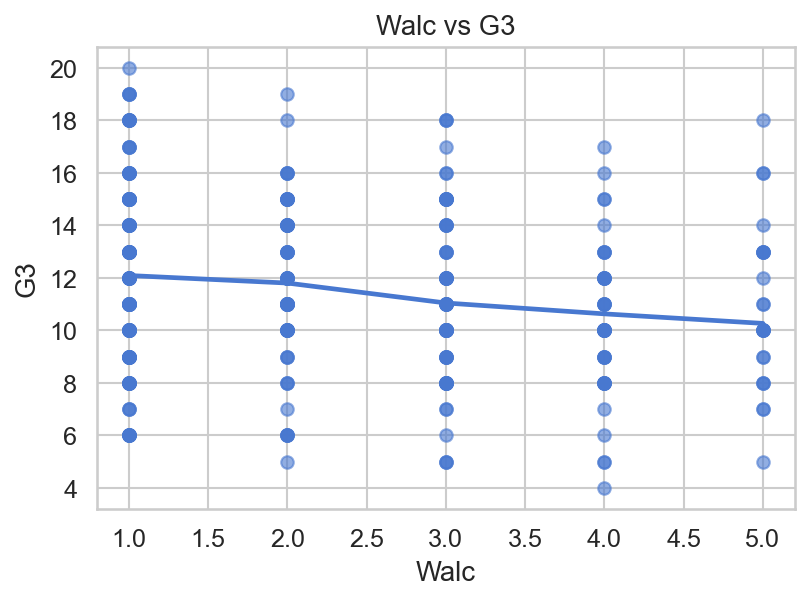

In [8]:
x = df_clean["Walc"]
y = df_clean["G3"]
rho, p = stats.spearmanr(x, y)
add_summary("H5: Walc vs G3", "Spearman", "rho", rho, p, "r", rho)

plt.figure(figsize=(6, 4))
sns.regplot(x=x, y=y, lowess=True, scatter_kws={"alpha": 0.6})
plt.title("Walc vs G3")
plt.savefig(f"{FIGURES_DIR}/hyp_h5_walc_g3.png")
plt.show()


### H6: Muốn học đại học (higher) và G3

Normality Check: {'no': {'stat': 0.9091716629889242, 'p': 0.15328028538919936}, 'yes': {'stat': 0.9813153785034406, 'p': 0.00019649067642174878}}, Normal OK: False


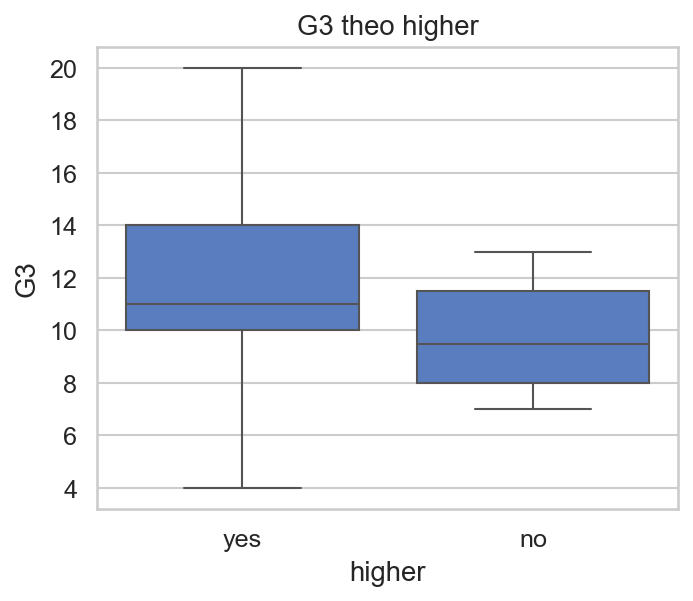

In [9]:
group_col = "higher"
target = "G3"
normality, normal_ok = shapiro_by_group(df_clean, group_col, target)
print(f"Normality Check: {normality}, Normal OK: {normal_ok}")

groups = [g[target].values for _, g in df_clean.groupby(group_col)]
x, y = groups[0], groups[1]

if normal_ok:
    t_stat, p = stats.ttest_ind(x, y, equal_var=False)
    d = cohen_d(x, y)
    add_summary("H6: higher vs G3", "Welch t-test", "t", t_stat, p, "Cohen's d", d)
else:
    u, p, r = mannwhitney_r(x, y)
    add_summary("H6: higher vs G3", "Mann-Whitney U", "U", u, p, "r", r)

plt.figure(figsize=(5, 4))
sns.boxplot(data=df_clean, x=group_col, y=target)
plt.title("G3 theo higher")
plt.savefig(f"{FIGURES_DIR}/hyp_h6_higher_g3.png")
plt.show()


### H7: Số lần trượt môn (failures) và G3

Normality Check: {0: {'stat': 0.9789332427938693, 'p': 0.0002516136616068129}, 1: {'stat': 0.9503763435386788, 'p': 0.07812598304417698}, 2: {'stat': 0.9318806728658718, 'p': 0.4004732166619736}, 3: {'stat': 0.8772919873634646, 'p': 0.09611082809222163}}, Normal OK: False


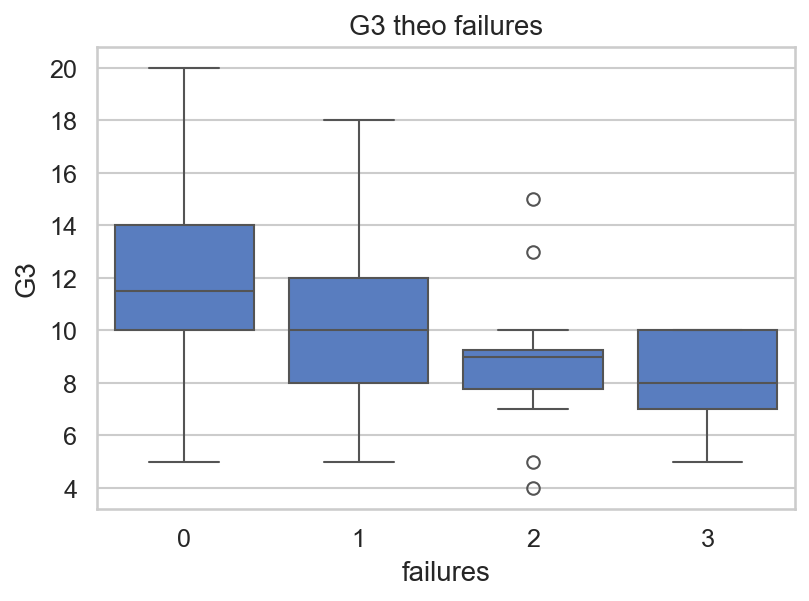

In [10]:
group_col = "failures"
target = "G3"
normality, normal_ok = shapiro_by_group(df_clean, group_col, target)
print(f"Normality Check: {normality}, Normal OK: {normal_ok}")

groups = [g[target].values for _, g in df_clean.groupby(group_col)]
k = len(groups)
n = sum(len(g) for g in groups)

if normal_ok:
    f_stat, p = stats.f_oneway(*groups)
    eta_sq = eta_squared_oneway(groups)
    add_summary("H7: failures vs G3", "One-way ANOVA", "F", f_stat, p, "eta^2", eta_sq)
else:
    h_stat, p = stats.kruskal(*groups)
    eps_sq = epsilon_squared_kruskal(h_stat, k, n)
    add_summary("H7: failures vs G3", "Kruskal-Wallis", "H", h_stat, p, "epsilon^2", eps_sq)

plt.figure(figsize=(6, 4))
sns.boxplot(data=df_clean, x=group_col, y=target)
plt.title("G3 theo failures")
plt.savefig(f"{FIGURES_DIR}/hyp_h7_failures_g3.png")
plt.show()


### H8: Trình độ học vấn bố/mẹ (Medu, Fedu) và G3

Medu Normality check: {0: {'stat': 0.7500000000000002, 'p': 7.771561172376096e-16}, 1: {'stat': 0.9700096324455624, 'p': 0.23165786564756563}, 2: {'stat': 0.9746241068577236, 'p': 0.07827386694567297}, 3: {'stat': 0.9694209448851215, 'p': 0.032198393769063194}, 4: {'stat': 0.9811869134664035, 'p': 0.07924217767981721}}, Normal OK: False
Fedu Normality check: {0: {'stat': nan, 'p': 0.0}, 1: {'stat': 0.9675871354123051, 'p': 0.0632241008676486}, 2: {'stat': 0.976564315990365, 'p': 0.0664688070751701}, 3: {'stat': 0.9675995809430917, 'p': 0.019626163340578116}, 4: {'stat': 0.9809712240951516, 'p': 0.22325781746726253}}, Normal OK: False


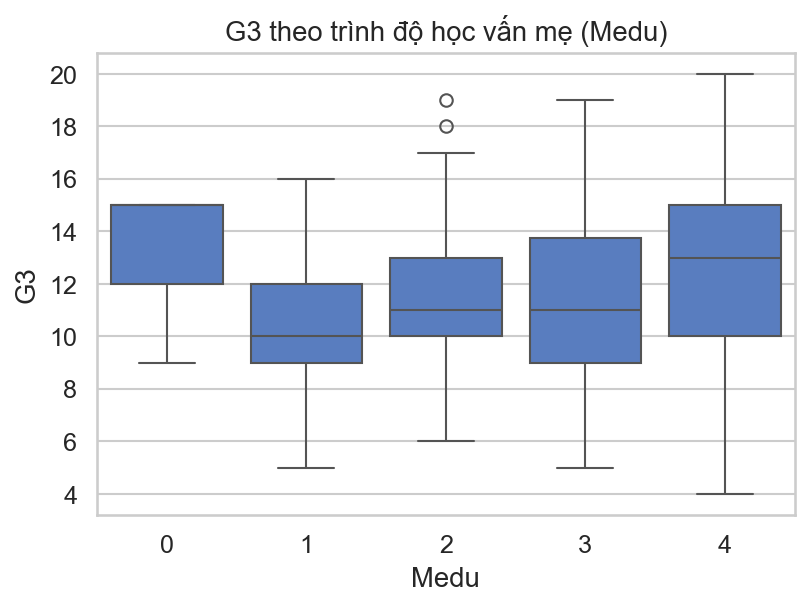

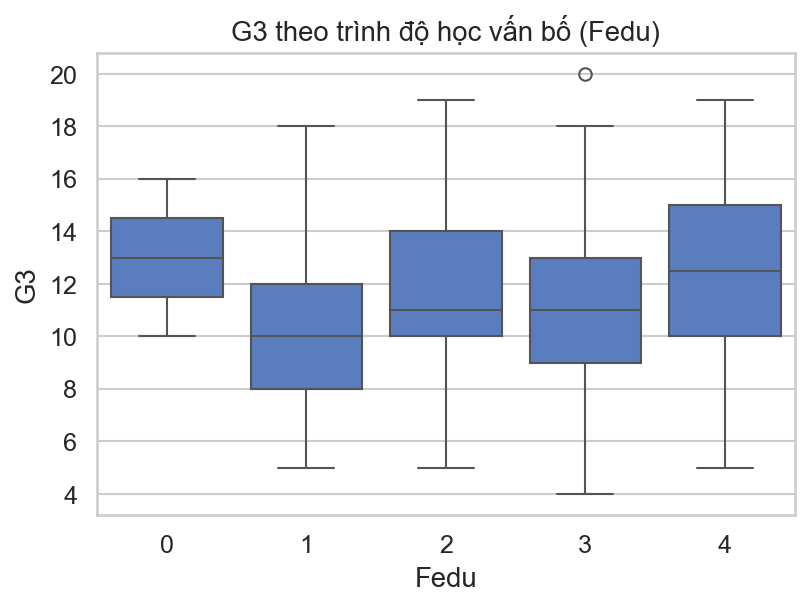

In [11]:
target = "G3"

# --- H8a: Medu vs G3 ---
group_col_m = "Medu"
normality_m, normal_ok_m = shapiro_by_group(df_clean, group_col_m, target)
print(f"Medu Normality check: {normality_m}, Normal OK: {normal_ok_m}")

groups_m = [g[target].values for _, g in df_clean.groupby(group_col_m)]
k_m = len(groups_m)
n_m = sum(len(g) for g in groups_m)

if normal_ok_m:
    f_stat, p = stats.f_oneway(*groups_m)
    eta_sq = eta_squared_oneway(groups_m)
    add_summary("H8a: Medu vs G3", "One-way ANOVA", "F", f_stat, p, "eta^2", eta_sq)
else:
    h_stat, p = stats.kruskal(*groups_m)
    eps_sq = epsilon_squared_kruskal(h_stat, k_m, n_m)
    add_summary("H8a: Medu vs G3", "Kruskal-Wallis", "H", h_stat, p, "epsilon^2", eps_sq)

# --- H8b: Fedu vs G3 ---
group_col_f = "Fedu"
normality_f, normal_ok_f = shapiro_by_group(df_clean, group_col_f, target)
print(f"Fedu Normality check: {normality_f}, Normal OK: {normal_ok_f}")

groups_f = [g[target].values for _, g in df_clean.groupby(group_col_f)]
k_f = len(groups_f)
n_f = sum(len(g) for g in groups_f)

if normal_ok_f:
    f_stat, p = stats.f_oneway(*groups_f)
    eta_sq = eta_squared_oneway(groups_f)
    add_summary("H8b: Fedu vs G3", "One-way ANOVA", "F", f_stat, p, "eta^2", eta_sq)
else:
    h_stat, p = stats.kruskal(*groups_f)
    eps_sq = epsilon_squared_kruskal(h_stat, k_f, n_f)
    add_summary("H8b: Fedu vs G3", "Kruskal-Wallis", "H", h_stat, p, "epsilon^2", eps_sq)

# --- Save Figures ---
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_clean, x=group_col_m, y=target)
plt.title("G3 theo trình độ học vấn mẹ (Medu)")
plt.savefig(f"{FIGURES_DIR}/hyp_h8a_medu_g3.png")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=df_clean, x=group_col_f, y=target)
plt.title("G3 theo trình độ học vấn bố (Fedu)")
plt.savefig(f"{FIGURES_DIR}/hyp_h8b_fedu_g3.png")
plt.show()


### H9 (post-hoc): Vắng mặt (absences) và G3

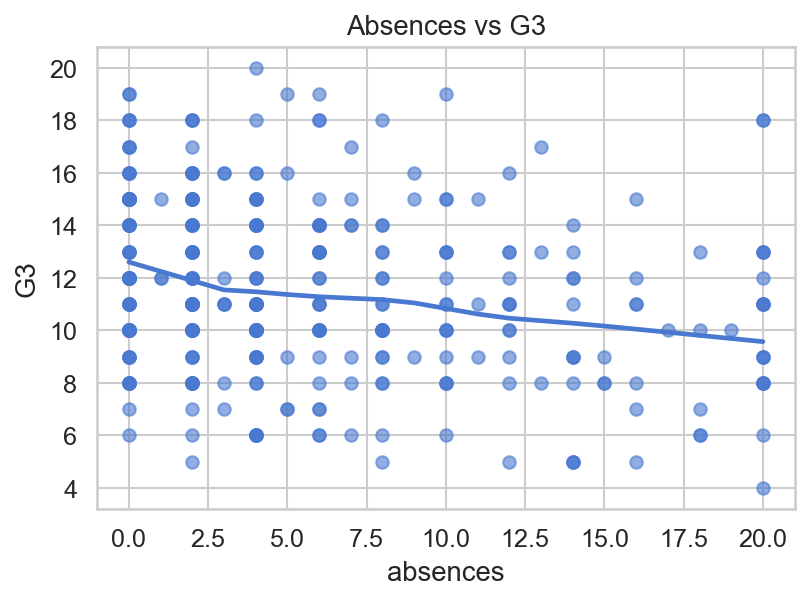

In [12]:
x = df_clean["absences"]
y = df_clean["G3"]
rho, p = stats.spearmanr(x, y)
add_summary("H9: absences vs G3", "Spearman", "rho", rho, p, "r", rho, note="post-hoc")

plt.figure(figsize=(6, 4))
sns.regplot(x=x, y=y, lowess=True, scatter_kws={"alpha": 0.6})
plt.title("Absences vs G3")
plt.savefig(f"{FIGURES_DIR}/hyp_h9_absences_g3.png")
plt.show()


## 4. Tổng hợp kết quả

In [13]:
summary_df = pd.DataFrame(summary_rows)
summary_df


,Hypothesis,Test,Statistic,Stat Value,p-value,Effect Size,Effect Value,Note
0,H1: sex vs G3,Mann-Whitney U,U,14190.500000,7.618077e-02,r,-0.093377,
1,H2: address vs G3,Mann-Whitney U,U,8954.500000,1.628410e-02,r,-0.126509,
2,H3: famsup vs G3,Mann-Whitney U,U,16269.500000,2.202940e-01,r,0.064545,
3,H4: studytime vs G3,Kruskal-Wallis,H,11.181389,1.078440e-02,epsilon^2,0.023177,
4,H5: Walc vs G3,Spearman,rho,-0.187439,3.698149e-04,r,-0.187439,
5,H6: higher vs G3,Mann-Whitney U,U,1510.500000,1.810930e-02,r,-0.124450,
6,H7: failures vs G3,Kruskal-Wallis,H,34.173115,1.821283e-07,epsilon^2,0.088309,
7,H8a: Medu vs G3,Kruskal-Wallis,H,16.910534,2.011862e-03,epsilon^2,0.036678,
8,H8b: Fedu vs G3,Kruskal-Wallis,H,14.863595,4.992654e-03,epsilon^2,0.030862,
9,H9: absences vs G3,Spearman,rho,-0.243119,3.361462e-06,r,-0.243119,post-hoc
